# CNN for Bias Detection in News Articles

This notebook implements a Convolutional Neural Network (CNN) to detect biased language in news articles.


In [29]:
DATA_PATH = "guardian_text.csv"

MAX_WORDS = 20000
MAX_LEN = 400
EMBEDDING_DIM = 100

BATCH_SIZE = 32
EPOCHS = 10
TEST_SIZE = 0.2
RANDOM_STATE = 42


## Import Required Libraries


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


## Load Dataset


In [31]:
df = pd.read_csv(DATA_PATH)
df.head()


,text,label
0,Ukrainian diplomats have been left frustrated ...,Neutral
1,To confront Donald Trump is to engage in asymm...,Biased
2,Two years of death and destruction in Gaza end...,Biased
3,A top aide to President Donald Trump has accus...,Neutral
4,12.54am BST We’re closing this blog soon. In t...,Neutral


## Encode Labels


In [32]:
texts = df["text"].astype(str)
labels = df["label"].map({"Neutral": 0, "Biased": 1}).values


## Tokenization
Convert text into sequences of word indices for CNN input.


In [33]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)


## Padding Sequences
Ensure all input sequences have the same length.


In [34]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X.shape


(5000, 400)

## Train-Test Split
Split the dataset into training and testing sets.


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels
)


## Build CNN Model
Construct a Convolutional Neural Network for text classification.


In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    Conv1D(filters=128, kernel_size=3, activation="relu"),
    GlobalMaxPooling1D(),

    Dense(64, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


a:\Python\Bias_Detection_in_News\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Training
Train the CNN on the training data.


In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)



Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.7272 - loss: 0.5636 - val_accuracy: 0.8675 - val_loss: 0.3707
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9044 - loss: 0.2564 - val_accuracy: 0.9225 - val_loss: 0.2210
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9731 - loss: 0.0939 - val_accuracy: 0.9175 - val_loss: 0.1886
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9953 - loss: 0.0269 - val_accuracy: 0.9400 - val_loss: 0.1716
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9997 - loss: 0.0097 - val_accuracy: 0.9400 - val_loss: 0.1799
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 0.9400 - val_loss: 0.1904


## Training Process and Learning Curve


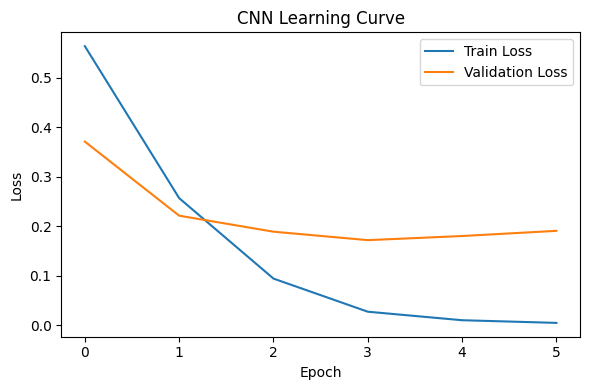

In [38]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Learning Curve")
plt.legend()
plt.tight_layout()
plt.savefig("CNN_LearningCurve.png")
plt.show()


## Model Evaluation
Evaluate CNN performance on the test set.


In [39]:
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       500
           1       0.93      0.95      0.94       500

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000

ROC AUC: 0.9837359999999999


## Confusion Matrix


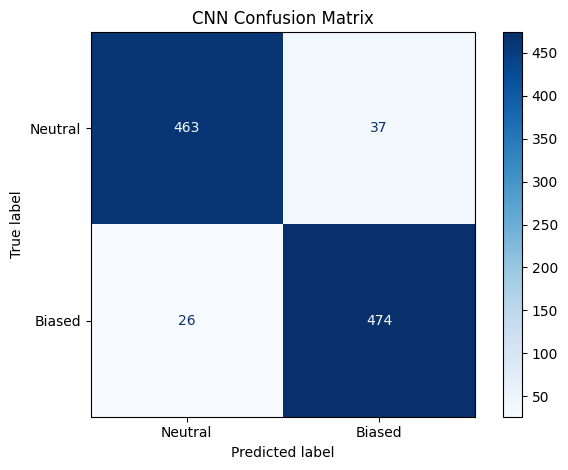

In [40]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Neutral", "Biased"]
)

disp.plot(cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.savefig("CNN_ConfusionMatrix.png")
plt.show()


## ROC Curve


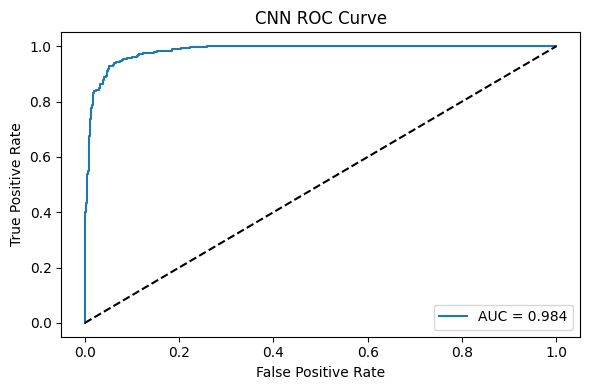

In [41]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("CNN_ROC.png")
plt.show()
